# 01 — Data cleaning & EDA

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/raw/GlobalWeatherRepository.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [2]:
df.shape

(167813, 41)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167813 entries, 0 to 167812
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       167813 non-null  str    
 1   location_name                 167813 non-null  str    
 2   latitude                      167813 non-null  float64
 3   longitude                     167813 non-null  float64
 4   timezone                      167813 non-null  str    
 5   last_updated_epoch            167813 non-null  int64  
 6   last_updated                  167813 non-null  str    
 7   temperature_celsius           167813 non-null  float64
 8   temperature_fahrenheit        167813 non-null  float64
 9   condition_text                167813 non-null  str    
 10  wind_mph                      167813 non-null  float64
 11  wind_kph                      167813 non-null  float64
 12  wind_degree                   167813 non-null  int64  


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
missing = df.isna().mean().sort_values(ascending=False)

In [6]:
missing.head(15)

country                   0.0
location_name             0.0
latitude                  0.0
longitude                 0.0
timezone                  0.0
last_updated_epoch        0.0
last_updated              0.0
temperature_celsius       0.0
temperature_fahrenheit    0.0
condition_text            0.0
wind_mph                  0.0
wind_kph                  0.0
wind_degree               0.0
wind_direction            0.0
pressure_mb               0.0
dtype: float64

In [7]:
[col for col in df.columns if "update" in col.lower() or "time" in col.lower()]

['timezone', 'last_updated_epoch', 'last_updated']

In [8]:
df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")
df["last_updated"].isna().mean()
df["last_updated"].describe()

count                        167813
mean     2025-07-22 17:37:46.317270
min             2024-05-16 01:45:00
25%             2024-12-19 06:30:00
50%             2025-07-22 11:30:00
75%             2026-02-23 12:45:00
max             2026-09-27 18:45:00
Name: last_updated, dtype: object

In [9]:
[col for col in df.columns if "temp" in col.lower() or "precip" in col.lower() or "rain" in col.lower()]

['temperature_celsius', 'temperature_fahrenheit', 'precip_mm', 'precip_in']

In [10]:
print(df["last_updated"].dtype)

datetime64[us]


In [11]:
print(df["last_updated"].isna().sum())

0


In [12]:
print(df.duplicated(subset=["location_name", "last_updated"]).sum())

1


In [13]:
dup_mask = df.duplicated(subset=["location_name", "last_updated"], keep=False)
df[dup_mask].sort_values(["location_name", "last_updated"]) #Seems like Nan is a place in Thailand, not NaN

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
125208,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,1771570800,2026-02-20 14:00:00,32.2,90.0,Partly Cloudy,...,21.55,21.55,2,2,06:42 AM,06:19 PM,08:21 AM,08:58 PM,Waxing Crescent,6
125244,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,1771570800,2026-02-20 14:00:00,32.2,90.0,Partly Cloudy,...,21.55,21.55,2,2,06:30 AM,06:54 PM,09:05 AM,09:14 PM,Waxing Crescent,8


In [14]:
df = df.drop_duplicates(subset=["location_name", "last_updated"], keep="first")

### Normalization

I did **not** apply min–max or z-score scaling to temperatures or lags; values stay in °C for interpretability. Forecasting uses raw lags on the same scale.


In [15]:
# IQR-based outliers (global scan — document only; no clipping)
num_cols = ["temperature_celsius", "humidity", "wind_kph", "pressure_mb", "precip_mm"]
num_cols = [c for c in num_cols if c in df.columns]
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: IQR outliers {n_out:,} ({100 * n_out / len(df):.2f}%)")

# Extreme values in raw scrape (global QA — Kyiv series unaffected)
qa_cols = [
    c
    for c in [
        "temperature_celsius",
        "pressure_mb",
        "wind_kph",
        "air_quality_Carbon_Monoxide",
    ]
    if c in df.columns
]
print("\nGlobal min/max (spot impossible readings):")
print(df[qa_cols].agg(["min", "max"]).T)

temperature_celsius: IQR outliers 3,120 (1.86%)
humidity: IQR outliers 2 (0.00%)
wind_kph: IQR outliers 3,180 (1.89%)
pressure_mb: IQR outliers 4,476 (2.67%)
precip_mm: IQR outliers 33,320 (19.86%)

Global min/max (spot impossible readings):
                                min        max
temperature_celsius           -29.8     79.300
pressure_mb                   771.0   3006.000
wind_kph                        3.6   2963.200
air_quality_Carbon_Monoxide -9999.0  38879.398


IQR flags are **climatic spread across 268 cities**, not bad Kyiv rows. Global min/max above surfaces scrape artifacts (e.g. extreme °C, pressure, wind, CO); I do not clip them for Kyiv forecasting.


In [16]:
df.shape

(167812, 41)

In [17]:
df.duplicated(subset=["location_name", "last_updated"]).sum()

np.int64(0)

In [18]:
#“Removed 1 duplicate row with identical (location_name, last_updated) and mostly matching weather fields, minor differences.”

In [19]:
city_counts = (
    df.groupby("location_name")["last_updated"]
    .agg(n_obs="count", start="min", end="max")
    .sort_values("n_obs", ascending=False)
)
city_counts.head(10)

,n_obs,start,end
location_name,,,
Sanaa,864,2024-05-16 11:45:00,2026-09-27 08:45:00
Baghdad,863,2024-05-16 11:45:00,2026-09-27 08:45:00
Asmara,863,2024-05-16 11:45:00,2026-09-27 08:45:00
Bujumbura,863,2024-05-16 10:45:00,2026-09-27 07:45:00
Bern,863,2024-05-16 10:45:00,2026-09-27 07:45:00
Accra,863,2024-05-16 08:45:00,2026-09-27 05:45:00
Kyiv,863,2024-05-16 11:45:00,2026-09-27 08:45:00
Dakar,863,2024-05-16 08:45:00,2026-09-27 05:30:00
Tashkent,863,2024-05-16 13:45:00,2026-09-27 10:45:00


<Axes: title={'center': 'Temperature — Kyiv'}, xlabel='last_updated'>

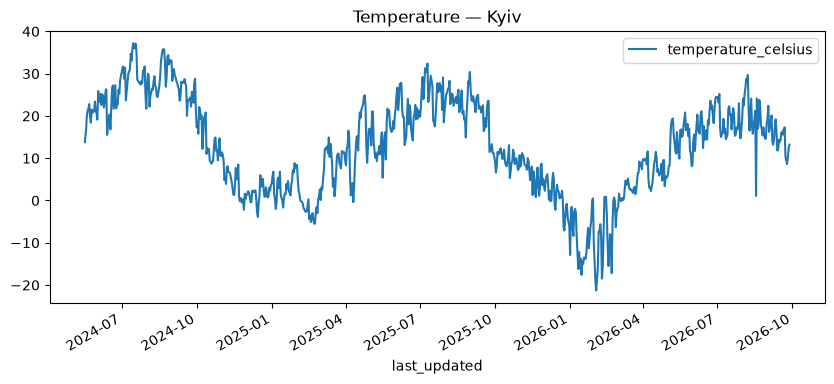

In [20]:
TARGET_CITY = "Kyiv"
city_df = (
    df.loc[df["location_name"] == TARGET_CITY, ["last_updated", "temperature_celsius", "precip_mm"]]
    .sort_values("last_updated")
    .reset_index(drop=True)
)

city_df.plot(x="last_updated", y="temperature_celsius", title=f"Temperature — {TARGET_CITY}", figsize=(10, 4))

<Axes: title={'center': 'Precipitation — Kyiv'}, xlabel='last_updated'>

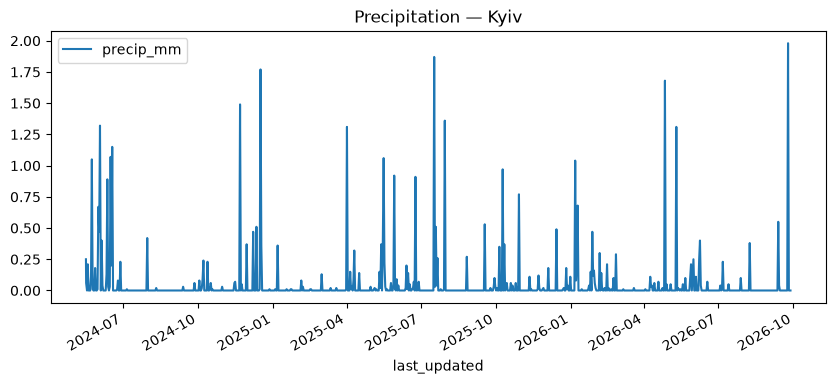

In [21]:
city_df.plot(x="last_updated", y="precip_mm", title=f"Precipitation — {TARGET_CITY}", figsize=(10, 4))

In [22]:
TARGET_CITY = "Kyiv"
city_df = (
    df.loc[df["location_name"] == TARGET_CITY, ["last_updated", "temperature_celsius", "precip_mm"]]
    .sort_values("last_updated")
    .reset_index(drop=True)
)
city_df.head()

,last_updated,temperature_celsius,precip_mm
0,2024-05-16 11:45:00,13.8,0.25
1,2024-05-16 17:00:00,14.6,0.06
2,2024-05-17 19:00:00,16.4,0.00
3,2024-05-18 17:30:00,19.8,0.21
4,2024-05-19 17:15:00,21.3,0.00


In [23]:
city_df.tail()

,last_updated,temperature_celsius,precip_mm
858,2026-09-23 08:45:00,9.5,0.00
859,2026-09-24 08:45:00,8.6,1.98
860,2026-09-25 08:45:00,10.2,0.00
861,2026-09-26 08:45:00,12.4,0.00
862,2026-09-27 08:45:00,13.2,0.00


In [24]:
city_df.shape

(863, 3)

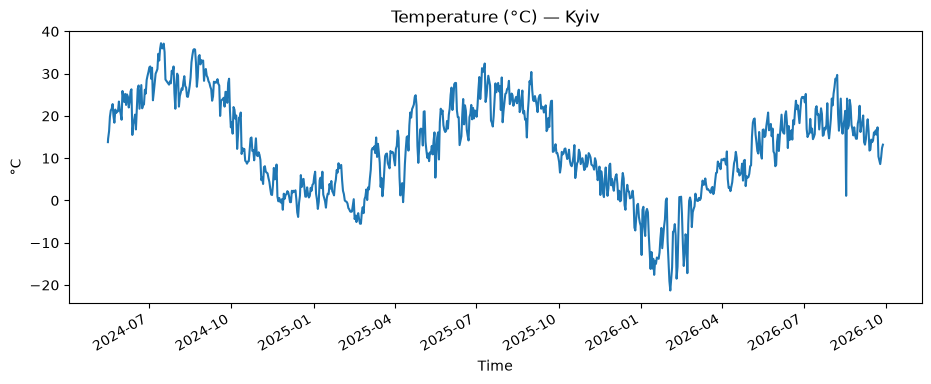

In [25]:
ax = city_df.plot(
    x="last_updated", y="temperature_celsius",
    title=f"Temperature (°C) — {TARGET_CITY}", figsize=(11, 4), legend=False
)
ax.set_xlabel("Time")
ax.set_ylabel("°C")
plt.savefig(f"../reports/kyiv_temperature.png", dpi=150, bbox_inches="tight")

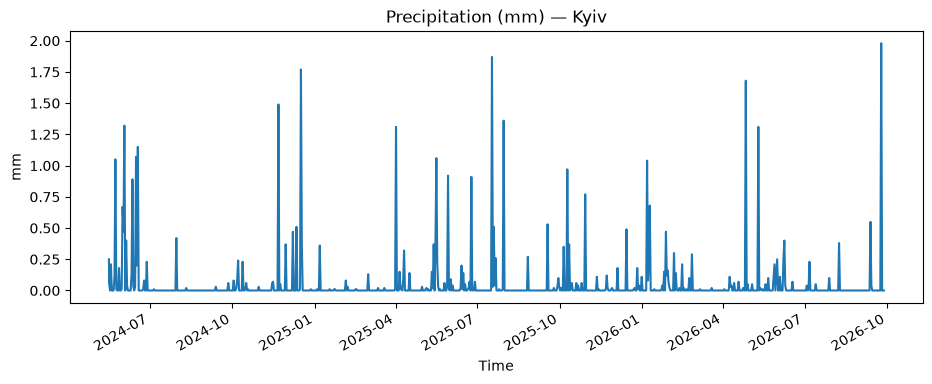

In [26]:
ax = city_df.plot(
    x="last_updated", y="precip_mm",
    title=f"Precipitation (mm) — {TARGET_CITY}", figsize=(11, 4), legend=False
)
ax.set_xlabel("Time")
ax.set_ylabel("mm")
plt.savefig(f"../reports/kyiv_precipitation.png", dpi=150, bbox_inches="tight")

In [27]:
delta = city_df["last_updated"].diff()
delta.describe()

count                       862
mean     1 days 00:03:07.935034
std      0 days 01:57:28.565106
min             0 days 05:15:00
25%             0 days 23:45:00
50%             1 days 00:00:00
75%             1 days 00:15:00
max             2 days 23:45:00
Name: last_updated, dtype: object

In [28]:
delta.value_counts().head(10)

last_updated
1 days 00:00:00    371
0 days 23:45:00    197
1 days 00:15:00    177
0 days 23:30:00     46
1 days 00:30:00     39
0 days 23:15:00      7
1 days 00:45:00      5
0 days 23:00:00      5
0 days 22:45:00      3
1 days 01:15:00      3
Name: count, dtype: int64

In [29]:
# Unfiltered country means (exploratory only — see notebook 03 for ≥100-row filter)
print(
    "For submission geo chart use notebook 03 (countries with ≥100 rows). "
    "Unfiltered means can inflate small countries (e.g. Saudi Arabien ~45°C)."
)
df.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False).head(10)

For submission geo chart use notebook 03 (countries with ≥100 rows). Unfiltered means can inflate small countries (e.g. Saudi Arabien ~45°C).


country
Saudi Arabien           45.000000
Marrocos                40.300000
Turkménistan            37.800000
Турция                  34.000000
Qatar                   32.963256
United Arab Emirates    32.550116
Cambodia                32.097329
Oman                    31.841183
Kuwait                  31.608943
Djibouti                31.519674
Name: temperature_celsius, dtype: float64